**Crop Recommendation System using Machine Learning based on Soil and Environmental Factors**

In [28]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utility
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
# Model saving
import joblib

In [29]:
# Print dataset shape
df = pd.read_csv('Crop_recommendation.csv')
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [30]:
# Check for missing values and data types
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicated Rows:", df.duplicated().sum())

# Describe numeric features
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicated Rows: 0


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


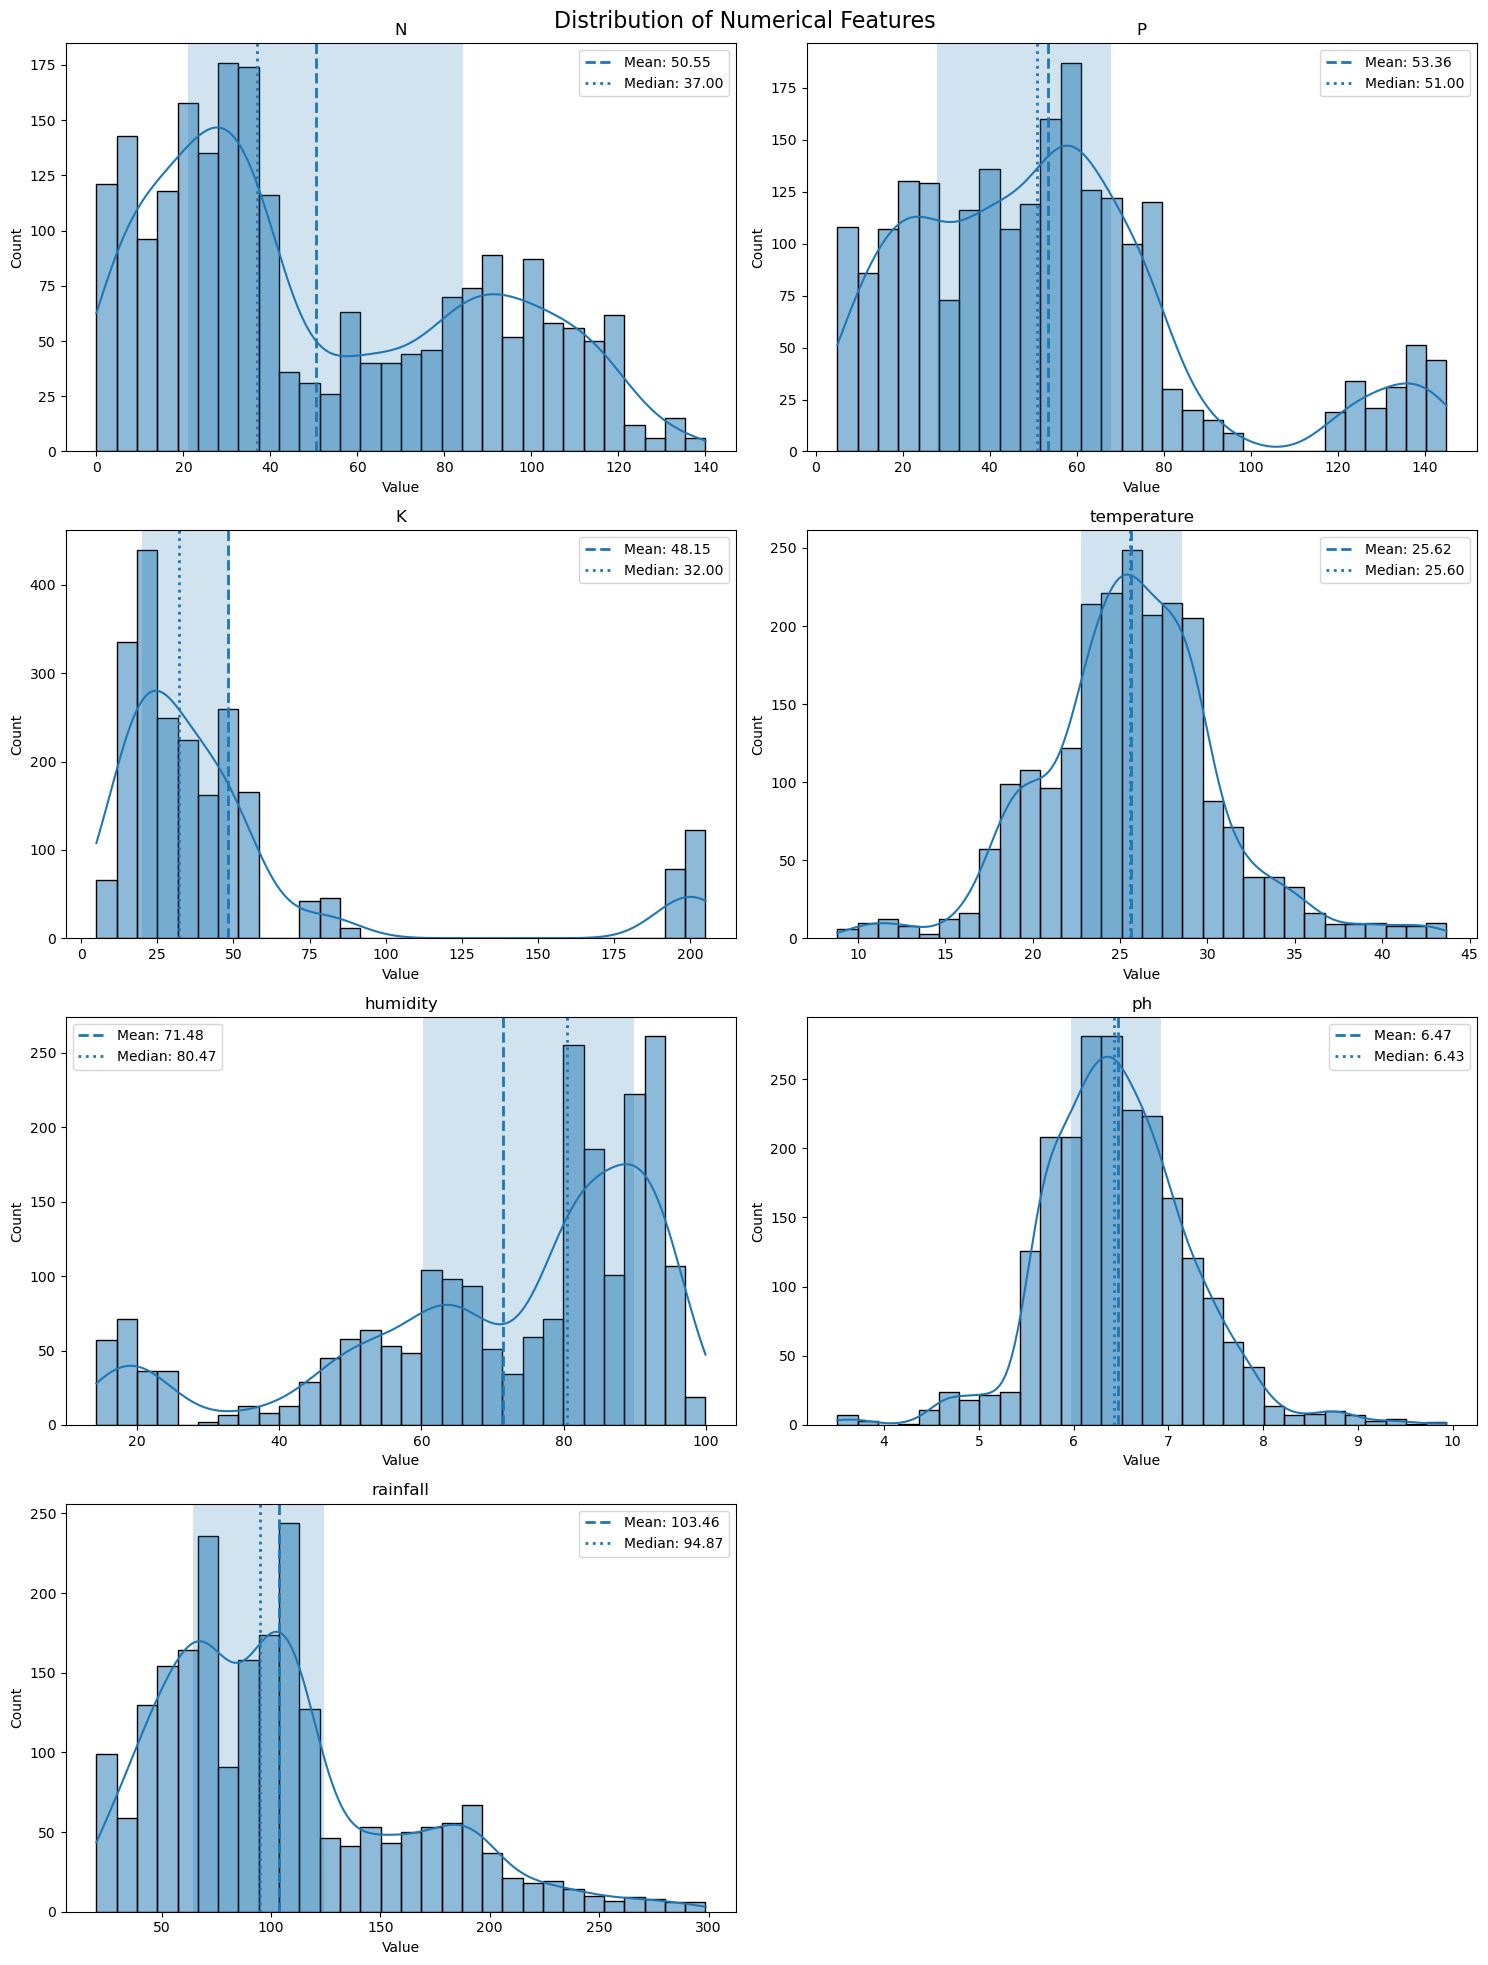

In [31]:
num_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    data = df[col]

    # Histogram with KDE
    sns.histplot(data, kde=True, ax=ax, bins=30)

    # Mean and Median
    mean_val = data.mean()
    median_val = data.median()

    ax.axvline(mean_val, linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, linestyle=':', linewidth=2, label=f'Median: {median_val:.2f}')

    # IQR shading
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    ax.axvspan(q1, q3, alpha=0.2)

    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

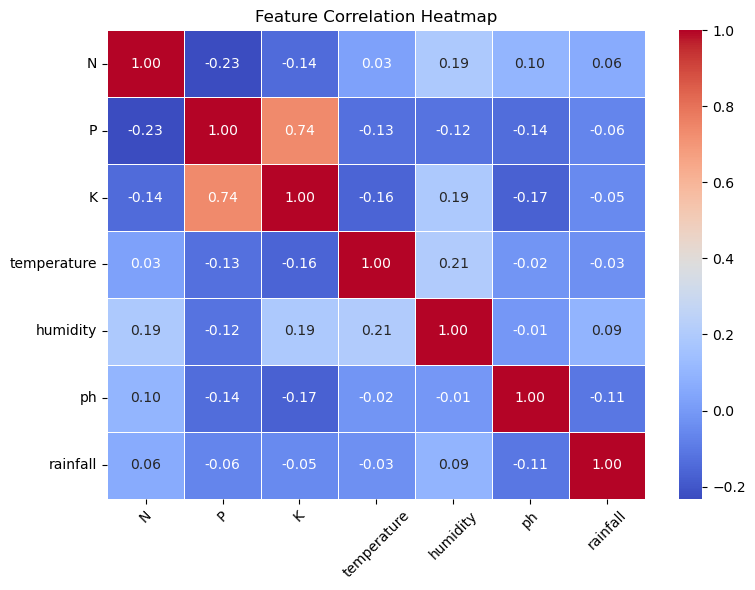

In [32]:
# Numerical features
num_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Correlation matrix
corr = df[num_features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

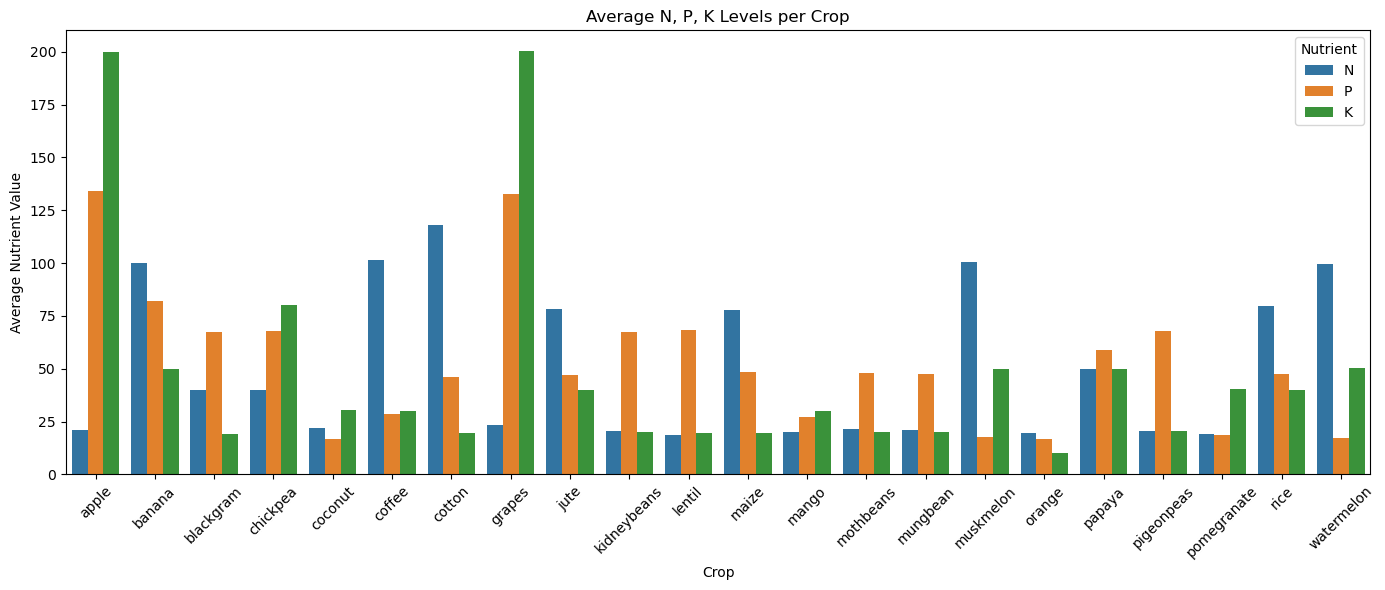

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average N, P, K per crop
avg_npk = df.groupby('label')[['N','P','K']].mean().reset_index()

# Convert to long format
avg_npk_melted = avg_npk.melt(id_vars='label',
                              var_name='Nutrient',
                              value_name='Average Value')

plt.figure(figsize=(14,6))

sns.barplot(
    data=avg_npk_melted,
    x='label',
    y='Average Value',
    hue='Nutrient'
)

plt.title("Average N, P, K Levels per Crop")
plt.xlabel("Crop")
plt.ylabel("Average Nutrient Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

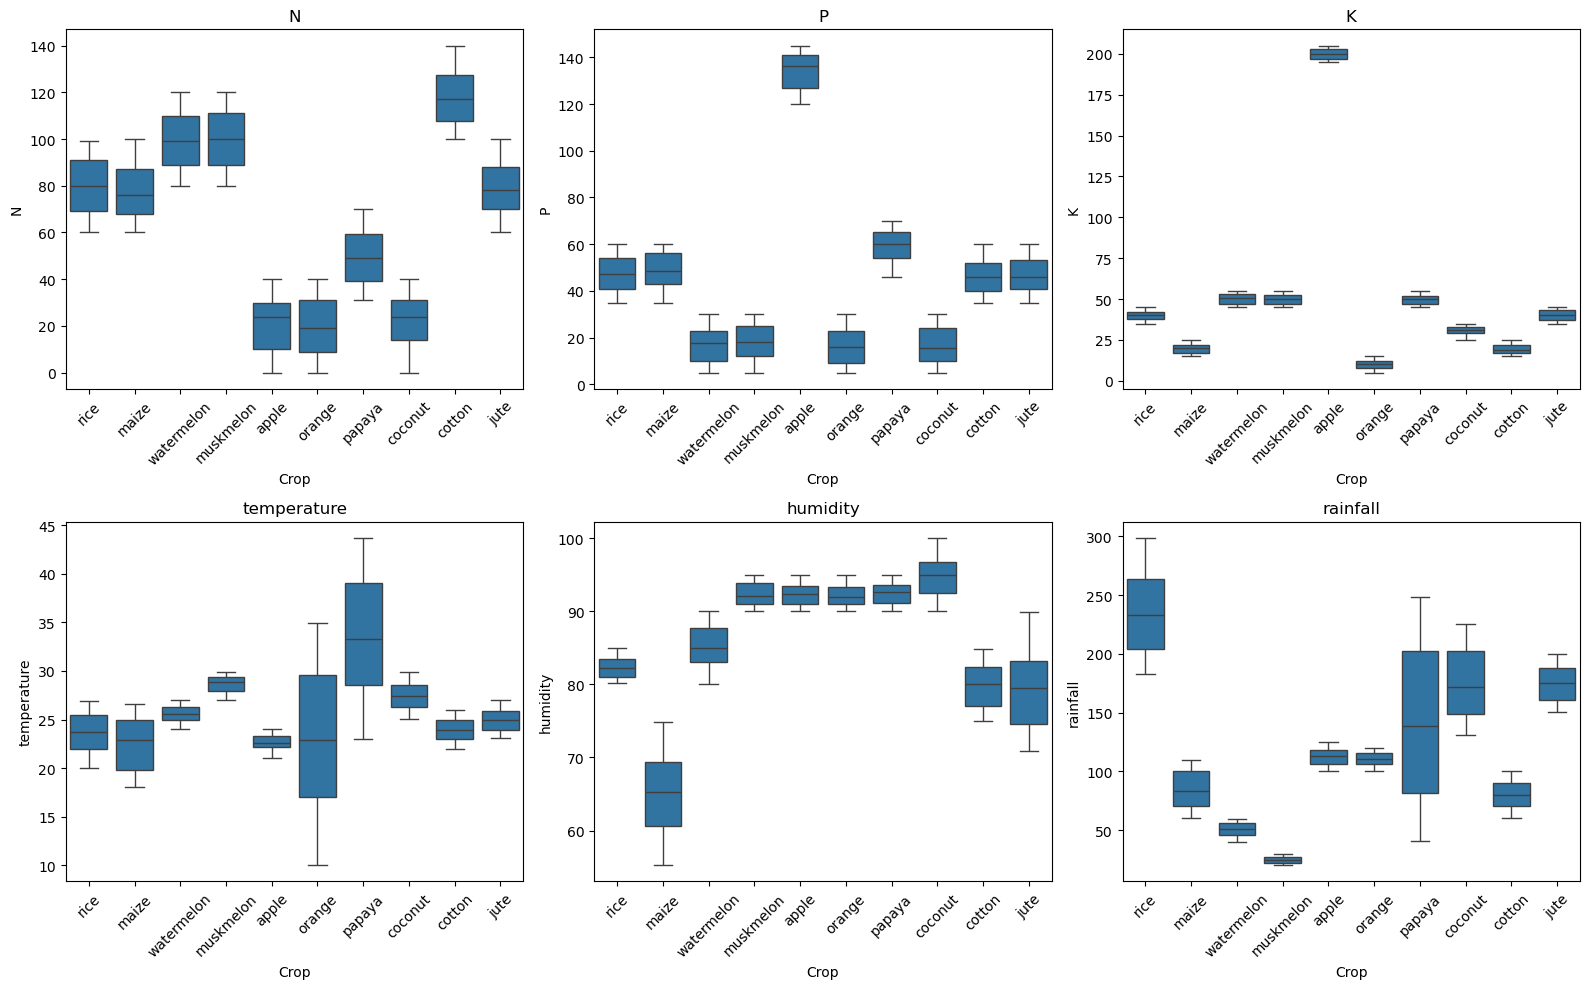

In [34]:
top_crops = df['label'].value_counts().head(10).index.tolist()

df_top = df[df['label'].isin(top_crops)]

features = ['N','P','K','temperature','humidity','rainfall']

fig, axes = plt.subplots(2,3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(features):
    
    sns.boxplot(
        data=df_top,
        x='label',
        y=col,
        ax=axes[i]
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Crop")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# Encode crop labels into numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['label_encoded'] = le.fit_transform(df['label'])

print("Encoded Classes:")
for i, crop in enumerate(le.classes_):
    print(i, "→", crop)

df.head()

Encoded Classes:
0 → apple
1 → banana
2 → blackgram
3 → chickpea
4 → coconut
5 → coffee
6 → cotton
7 → grapes
8 → jute
9 → kidneybeans
10 → lentil
11 → maize
12 → mango
13 → mothbeans
14 → mungbean
15 → muskmelon
16 → orange
17 → papaya
18 → pigeonpeas
19 → pomegranate
20 → rice
21 → watermelon


,N,P,K,temperature,humidity,ph,rainfall,label,label_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20


In [36]:
# Features (input variables)
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]

# Target
y = df['label_encoded']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2200, 7)
Target Shape: (2200,)


In [37]:
# Split dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1760, 7)
Testing samples: (440, 7)


In [38]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred_rf = rf_model.predict(X_test)

In [40]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9954545454545455

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16 

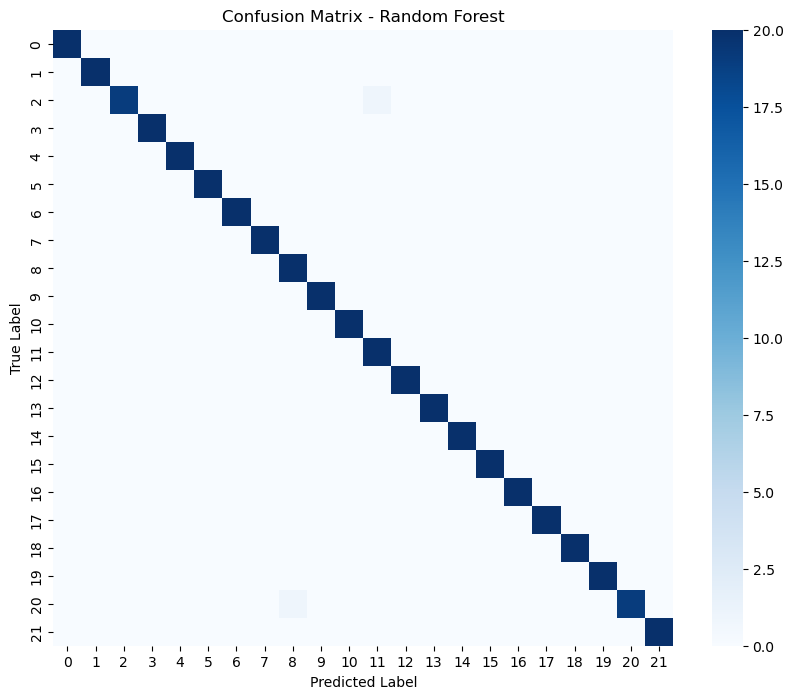

In [41]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

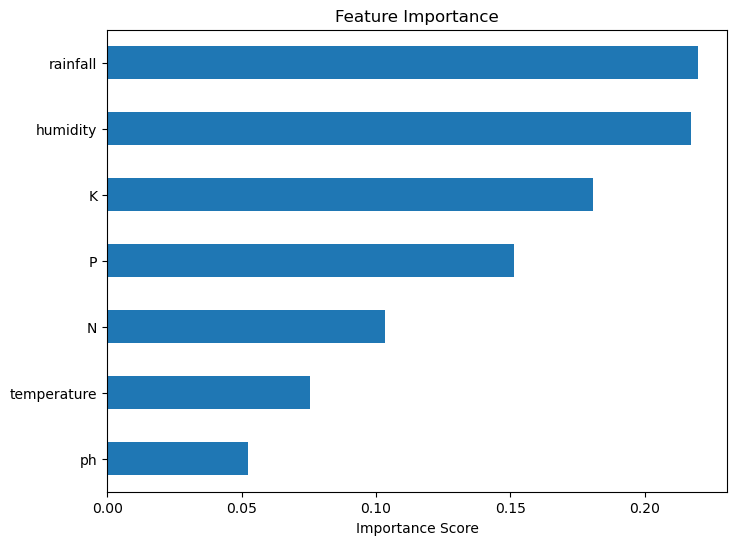

In [42]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.show()

In [43]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    results[name] = acc

results

{'Random Forest': 0.9954545454545455,
 'SVM': 0.9840909090909091,
 'XGBoost': 0.9931818181818182}

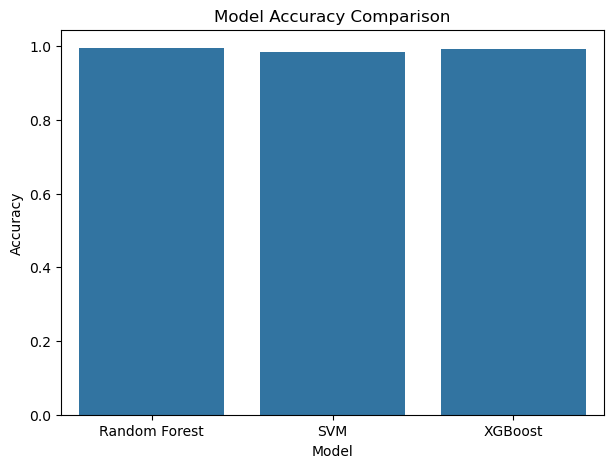

In [44]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

In [45]:
joblib.dump(rf_model, "crop_recommendation_model.pkl")

print("Model saved successfully")

Model saved successfully


In [46]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    
    prediction = rf_model.predict(input_data)
    
    crop_name = le.inverse_transform(prediction)
    
    return crop_name[0]

In [48]:
recommend_crop(
    N=71,
    P=60,
    K=22,
    temperature=26,
    humidity=71,
    ph=6.2,
    rainfall=79.8
)

'maize'